In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Dataset

In [2]:
# Load train.csv
df = pd.read_csv("train.csv")

# Tampilkan info dasar
print(f"Shape dataset: {df.shape}")
print("\n--- Info Dataset ---\n")
display(df.info())
print("\n--- Head Dataset ---")
display(df.head())
print("\n--- Deskripsi Dataset ---")
display(df.describe())

Shape dataset: (103904, 6)

--- Info Dataset ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Type of Travel          103904 non-null  object
 1   Class                   103904 non-null  object
 2   Inflight wifi service   103904 non-null  int64 
 3   Online boarding         103904 non-null  int64 
 4   Inflight entertainment  103904 non-null  int64 
 5   satisfaction            103904 non-null  object
dtypes: int64(3), object(3)
memory usage: 4.8+ MB


None


--- Head Dataset ---


,Type of Travel,Class,Inflight wifi service,Online boarding,Inflight entertainment,satisfaction
0,Personal Travel,Eco Plus,3,3,5,neutral or dissatisfied
1,Business travel,Business,3,3,1,neutral or dissatisfied
2,Business travel,Business,2,5,5,satisfied
3,Business travel,Business,2,2,2,neutral or dissatisfied
4,Business travel,Business,3,5,3,satisfied



--- Deskripsi Dataset ---


,Inflight wifi service,Online boarding,Inflight entertainment
count,103904.000000,103904.000000,103904.000000
mean,2.729683,3.250375,3.358158
std,1.327829,1.349509,1.332991
min,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000
50%,3.000000,3.000000,4.000000
75%,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000


# 2. Encoding Teks -> Angka

In [3]:
travel_mapping = {"Personal Travel": 0, "Business travel": 1}
class_mapping = {"Eco": 0, "Eco Plus": 1, "Business": 2}
satisfaction_mapping = {"neutral or dissatisfied": 0, "satisfied": 1}

df_encoded = df.copy()
df_encoded["Type of Travel"] = df_encoded["Type of Travel"].map(travel_mapping)
df_encoded["Class"] = df_encoded["Class"].map(class_mapping)
df_encoded["satisfaction"] = df_encoded["satisfaction"].map(satisfaction_mapping)

print("\n--- Head Dataset (Encoded) ---")
display(df_encoded.head())
print("\n--- Deskripsi Dataset (Encoded) ---")
display(df_encoded.describe())


--- Head Dataset (Encoded) ---


,Type of Travel,Class,Inflight wifi service,Online boarding,Inflight entertainment,satisfaction
0,0,1,3,3,5,0
1,1,2,3,3,1,0
2,1,2,2,5,5,1
3,1,2,2,2,2,0
4,1,2,3,5,3,1



--- Deskripsi Dataset (Encoded) ---


,Type of Travel,Class,Inflight wifi service,Online boarding,Inflight entertainment,satisfaction
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000
mean,0.689627,1.028103,2.729683,3.250375,3.358158,0.433333
std,0.462649,0.962858,1.327829,1.349509,1.332991,0.495538
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000,2.000000,2.000000,0.000000
50%,1.000000,1.000000,3.000000,3.000000,4.000000,0.000000
75%,1.000000,2.000000,4.000000,4.000000,4.000000,1.000000
max,1.000000,2.000000,5.000000,5.000000,5.000000,1.000000


# 3. Fungsi Keanggotaan

In [4]:
def trimf(x, abc):
    a, b, c = abc
    if x < a or x > c:
        return 0.0
    if b == a and x == a:
        return 1.0
    if b == c and x == c:
        return 1.0
    if x <= b:
        if a != b: return (x-a)/(b-a)
        else: return 1.0
    else:
        if b != c: return (c-x)/(c-b)
        else: return 1.0

def zmf(x, a, b):
    if x <= a: return 1.0
    if x >= b: return 0.0
    return (b-x)/(b-a)

def smf(x, a, b):
    if x <= a: return 0.0
    if x >= b: return 1.0
    return (x-a)/(b-a)

# 4. Variable linguistic


In [5]:
MF_SERVICE = {
    'buruk':  [0, 0, 2.5],
    'sedang': [0, 2.5, 5],
    'baik':   [2.5, 5, 5],
}

MF_CLASS = {
    'rendah':   ('zmf', 0, 1),
    'menengah': ('trimf', [0, 1, 2]),
    'tinggi':   ('smf', 1, 2),
}

MF_TRAVEL = {
    'personal': ('zmf', 0, 1),
    'bisnis':   ('smf', 0, 1),
}

MF_OUTPUT = {
    'tidak_puas': [0, 0, 50],
    'netral':     [0, 50, 100],
    'puas':       [50, 100, 100],
}

UNIVERSE_OUTPUT = np.linspace(0, 100, 101)

def eval_mf(val, mf_spec):
    mf_type = mf_spec[0]
    if mf_type == 'trimf':
        return trimf(val, mf_spec[1])
    elif mf_type == 'zmf':
        return zmf(val, mf_spec[1], mf_spec[2])
    elif mf_type == 'smf':
        return smf(val, mf_spec[1], mf_spec[2])

# 5. Visualisasi Fungsi Keanggotaan

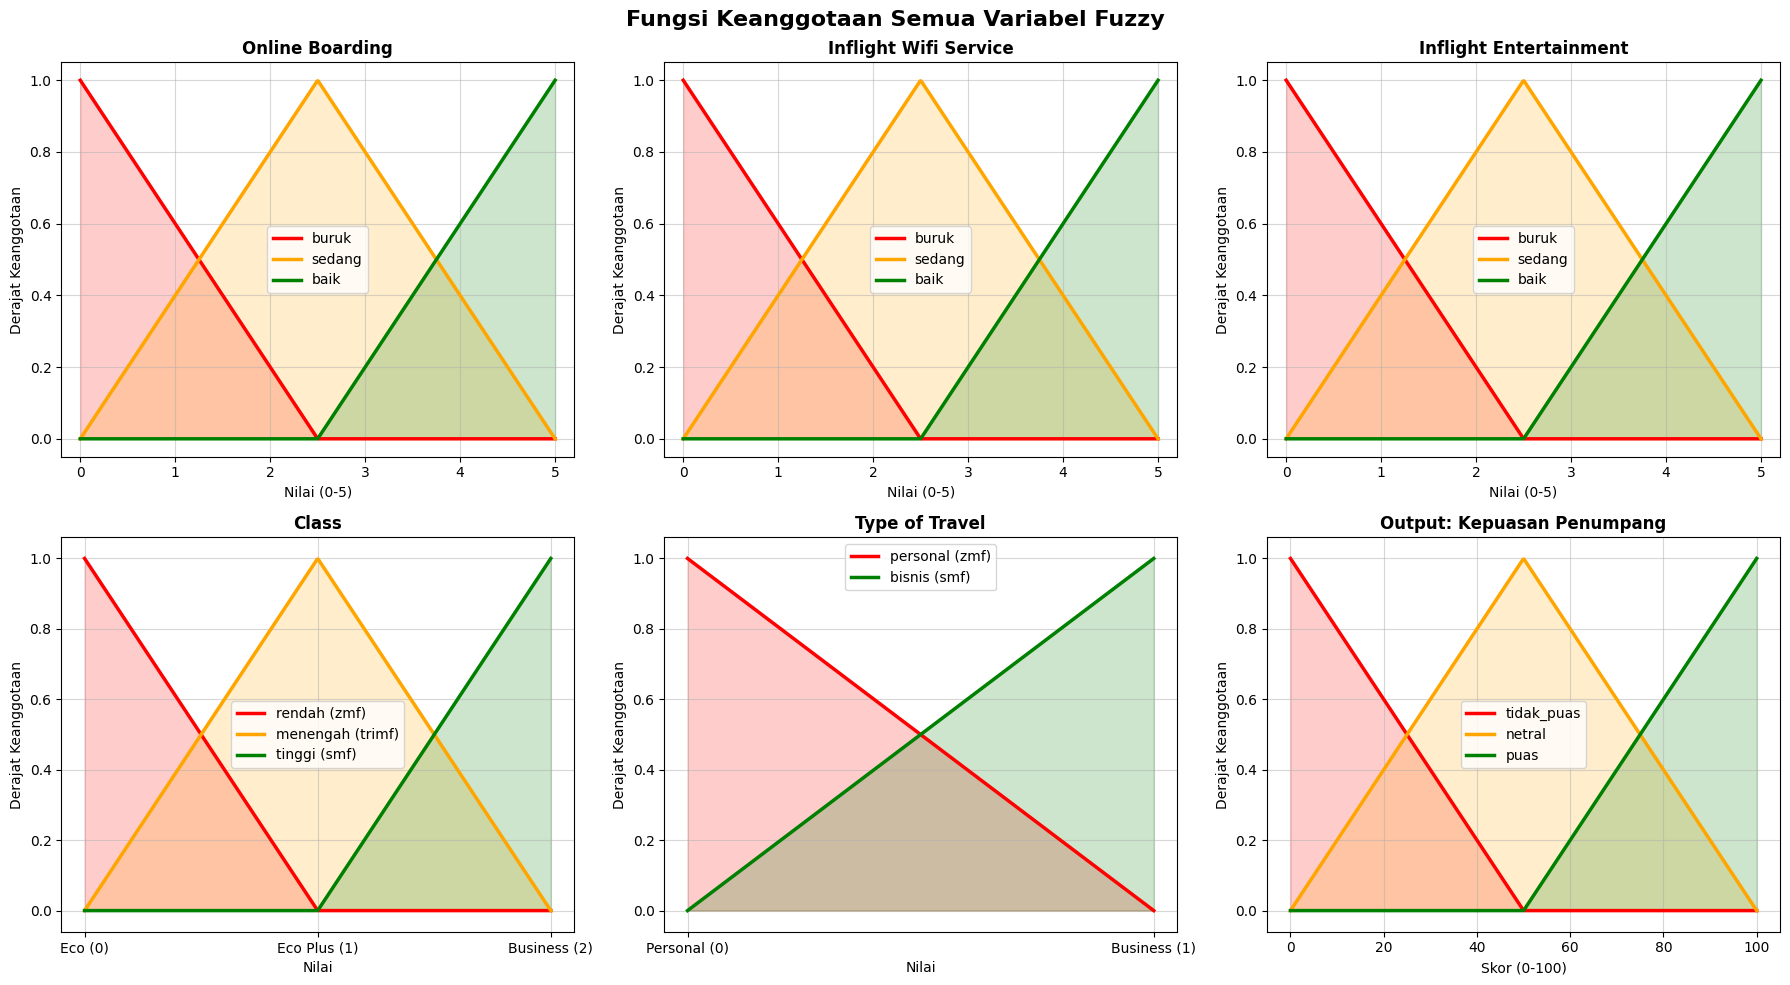

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fungsi Keanggotaan Semua Variabel Fuzzy', fontsize=16, fontweight='bold')

palette = {'buruk': 'red', 'sedang': 'orange', 'baik': 'green',
           'rendah': 'red', 'menengah': 'orange', 'tinggi': 'green',
           'personal': 'red', 'bisnis': 'green',
           'tidak_puas': 'red', 'netral': 'orange', 'puas': 'green'}

# Plot 1, 2, 3: Online boarding, Wifi, Entertainment
titles = ['Online Boarding', 'Inflight Wifi Service', 'Inflight Entertainment']
u_serv = np.linspace(0, 5, 500)
for i, title in enumerate(titles):
    ax = axes[0, i]
    for label, params in MF_SERVICE.items():
        y = [trimf(x, params) for x in u_serv]
        ax.plot(u_serv, y, label=label, color=palette[label], linewidth=2.5)
        ax.fill_between(u_serv, y, alpha=0.2, color=palette[label])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Nilai (0-5)')
    ax.set_ylabel('Derajat Keanggotaan')
    ax.set_xlim(-0.2, 5.2)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.5)
    ax.legend()

# Plot 4: Class
ax_cls = axes[1, 0]
u_cls = np.linspace(0, 2, 500)
for label, spec in MF_CLASS.items():
    y = [eval_mf(x, spec) for x in u_cls]
    ax_cls.plot(u_cls, y, label=f"{label} ({spec[0]})", color=palette[label], linewidth=2.5)
    ax_cls.fill_between(u_cls, y, alpha=0.2, color=palette[label])
ax_cls.set_title('Class', fontweight='bold')
ax_cls.set_xlabel('Nilai')
ax_cls.set_ylabel('Derajat Keanggotaan')
ax_cls.set_xticks([0, 1, 2])
ax_cls.set_xticklabels(['Eco (0)', 'Eco Plus (1)', 'Business (2)'])
ax_cls.set_ylim(-0.06, 1.06)
ax_cls.grid(True, alpha=0.5)
ax_cls.legend()

# Plot 5: Type of Travel
ax_trv = axes[1, 1]
u_trv = np.linspace(0, 1, 500)
for label, spec in MF_TRAVEL.items():
    y = [eval_mf(x, spec) for x in u_trv]
    ax_trv.plot(u_trv, y, label=f"{label} ({spec[0]})", color=palette[label], linewidth=2.5)
    ax_trv.fill_between(u_trv, y, alpha=0.2, color=palette[label])
ax_trv.set_title('Type of Travel', fontweight='bold')
ax_trv.set_xlabel('Nilai')
ax_trv.set_ylabel('Derajat Keanggotaan')
ax_trv.set_xticks([0, 1])
ax_trv.set_xticklabels(['Personal (0)', 'Business (1)'])
ax_trv.set_ylim(-0.06, 1.06)
ax_trv.grid(True, alpha=0.5)
ax_trv.legend()

# Plot 6: Output Satisfaction
ax_out = axes[1, 2]
u_out = np.linspace(0, 100, 500)
for label, params in MF_OUTPUT.items():
    y = [trimf(x, params) for x in u_out]
    ax_out.plot(u_out, y, label=label, color=palette[label], linewidth=2.5)
    ax_out.fill_between(u_out, y, alpha=0.2, color=palette[label])
ax_out.set_title('Output: Kepuasan Penumpang', fontweight='bold')
ax_out.set_xlabel('Skor (0-100)')
ax_out.set_ylabel('Derajat Keanggotaan')
ax_out.set_xlim(-5, 105)
ax_out.set_ylim(-0.06, 1.06)
ax_out.grid(True, alpha=0.5)
ax_out.legend()

plt.tight_layout()
plt.show()

# 6. Rule Base

In [7]:
# ob = ['Online boarding']
# wifi = ['Inflight wifi service']
# ent = ['Inflight entertainment']
# cls = ['Class']
# trav = ['Type of Travel']

RULES = [
    # PUAS
    {'id': 1, 'ant': [('ob','baik'),('wifi','baik'),('ent','baik')],                            'con': 'puas'},
    {'id': 2, 'ant': [('ob','baik'),('cls','tinggi')],                                          'con': 'puas'},
    {'id': 3, 'ant': [('ob','baik'),('ent','baik')],                                            'con': 'puas'},
    {'id': 4, 'ant': [('wifi','baik'),('ent','baik'),('cls','tinggi')],                         'con': 'puas'},
    {'id': 5, 'ant': [('ob','baik'),('wifi','sedang'),('ent','baik')],                          'con': 'puas'},
    {'id': 6, 'ant': [('ob','sedang'),('wifi','baik'),('cls','tinggi')],                        'con': 'puas'},
    {'id': 7, 'ant': [('trav','bisnis'),('ob','baik'),('wifi','baik')],                         'con': 'puas'},
    {'id': 8, 'ant': [('trav','bisnis'),('cls','tinggi'),('wifi','baik'),('ent','baik')],       'con': 'puas'},

    # NETRAL
    {'id': 9, 'ant': [('ob','sedang'),('wifi','sedang'),('ent','sedang')],                      'con': 'netral'},
    {'id': 10, 'ant': [('ob','sedang'),('cls','menengah')],                                     'con': 'netral'},
    {'id': 11, 'ant': [('trav','bisnis'),('cls','tinggi'),('ob','sedang')],                     'con': 'netral'},
    {'id': 12, 'ant': [('ob','sedang'),('ent','sedang'),('cls','rendah')],                      'con': 'netral'},
    {'id': 13, 'ant': [('ob','sedang'),('wifi','sedang'),('cls','menengah'),('trav','bisnis')], 'con': 'netral'},

    # TIDAK PUAS
    {'id': 14, 'ant': [('ob','buruk'),('wifi','buruk'),('ent','buruk')],                        'con': 'tidak_puas'},
    {'id': 15, 'ant': [('ob','buruk'),('cls','rendah')],                                        'con': 'tidak_puas'},
    {'id': 16, 'ant': [('wifi','buruk'),('ent','buruk')],                                       'con': 'tidak_puas'},
    {'id': 17, 'ant': [('trav','personal'),('cls','rendah'),('ob','buruk')],                    'con': 'tidak_puas'},
    {'id': 18, 'ant': [('trav','personal'),('ob','buruk'),('ent','buruk')],                     'con': 'tidak_puas'},
    {'id': 19, 'ant': [('ob','buruk'),('wifi','sedang'),('cls','rendah')],                      'con': 'tidak_puas'},
    {'id': 20, 'ant': [('trav','personal'),('cls','rendah'),('wifi','buruk'),('ent','buruk')],  'con': 'tidak_puas'},
]

# 7. Fuzzifikasi

In [8]:
def fuzzify(row):
    ob = row['Online boarding']
    wifi = row['Inflight wifi service']
    ent = row['Inflight entertainment']
    cls = row['Class']
    trav = row['Type of Travel']

    return {
        'ob': {
            'buruk':  trimf(ob, MF_SERVICE['buruk']),
            'sedang': trimf(ob, MF_SERVICE['sedang']),
            'baik':   trimf(ob, MF_SERVICE['baik']),
        },
        'wifi': {
            'buruk':  trimf(wifi, MF_SERVICE['buruk']),
            'sedang': trimf(wifi, MF_SERVICE['sedang']),
            'baik':   trimf(wifi, MF_SERVICE['baik']),
        },
        'ent': {
            'buruk':  trimf(ent, MF_SERVICE['buruk']),
            'sedang': trimf(ent, MF_SERVICE['sedang']),
            'baik':   trimf(ent, MF_SERVICE['baik']),
        },
        'cls': {
            'rendah':   eval_mf(cls, MF_CLASS['rendah']),
            'menengah': eval_mf(cls, MF_CLASS['menengah']),
            'tinggi':   eval_mf(cls, MF_CLASS['tinggi']),
        },
        'trav': {
            'personal': eval_mf(trav, MF_TRAVEL['personal']),
            'bisnis':   eval_mf(trav, MF_TRAVEL['bisnis']),
        },
    }

# 8. Inferensi

In [9]:
def inferensi(fuzzified):
    results = []
    for rule in RULES:
        strengths = [
            fuzzified[var][himpunan]
            for var, himpunan in rule['ant']
        ]
        firing_strength = min(strengths) if strengths else 0.0

        results.append((rule['id'], firing_strength, rule['con']))
    return results

#9. Defuzzifikasi Mamdani

In [10]:
def mamdani_defuzz(inference_results):

    aggregated = []

    for x in UNIVERSE_OUTPUT:

        max_membership = 0

        for _, firing_strength, conclusion in inference_results:

            output_membership = trimf(
                x,
                MF_OUTPUT[conclusion]
            )

            clipped = min(
                firing_strength,
                output_membership
            )

            if clipped > max_membership:
                max_membership = clipped

        aggregated.append(max_membership)

    numerator = 0
    denominator = 0

    for i in range(len(UNIVERSE_OUTPUT)):
        numerator += (
            UNIVERSE_OUTPUT[i]
            *
            aggregated[i]
        )

        denominator += aggregated[i]

    if denominator == 0:
        return 50

    return numerator / denominator

#10. Defuzzifikasi Sugeno

In [11]:
SUGENO_OUTPUT = {
    'tidak_puas': 25,
    'netral': 50,
    'puas': 75
}

def sugeno_defuzz(inference_results):

    numerator = 0
    denominator = 0

    for _, firing_strength, conclusion in inference_results:

        numerator += (
            firing_strength *
            SUGENO_OUTPUT[conclusion]
        )

        denominator += firing_strength

    if denominator == 0:
        return 50

    return numerator / denominator

#11. Contoh Proses Fuzzy pada 1 Data

In [12]:
sample = df_encoded.iloc[0]

fuzzified = fuzzify(sample)

inference_result = inferensi(fuzzified)

print("===== HASIL INFERENSI =====")

for rule_id, strength, conclusion in inference_result:

    if strength > 0:

        print(
            f"Rule {rule_id} "
            f"-> {strength:.3f} "
            f"-> {conclusion}"
        )

mamdani_score = mamdani_defuzz(
    inference_result
)

sugeno_score = sugeno_defuzz(
    inference_result
)

print("\nMamdani :", round(mamdani_score,2))
print("Sugeno  :", round(sugeno_score,2))

===== HASIL INFERENSI =====
Rule 1 -> 0.200 -> puas
Rule 3 -> 0.200 -> puas
Rule 5 -> 0.200 -> puas
Rule 10 -> 0.800 -> netral

Mamdani : 51.05
Sugeno  : 60.71


#12. Prediksi Seluruh Dataset

In [13]:
mamdani_scores = []
sugeno_scores = []

for _, row in df_encoded.iterrows():

    fuzzified = fuzzify(row)

    inference_result = inferensi(fuzzified)

    mamdani_scores.append(
        mamdani_defuzz(
            inference_result
        )
    )

    sugeno_scores.append(
        sugeno_defuzz(
            inference_result
        )
    )

df_encoded["mamdani_score"] = mamdani_scores
df_encoded["sugeno_score"] = sugeno_scores

display(
    df_encoded[
        [
            "mamdani_score",
            "sugeno_score"
        ]
    ].head()
)

,mamdani_score,sugeno_score
0,51.052953,60.714286
1,51.052953,58.333333
2,83.666667,75.000000
3,48.947047,45.000000
4,83.666667,75.000000


#13. Konversi Menjadi Label Kelas

In [14]:
pred_mamdani = []
pred_sugeno = []

for score in df_encoded["mamdani_score"]:

    if score >= 50:
        pred_mamdani.append(1)
    else:
        pred_mamdani.append(0)

for score in df_encoded["sugeno_score"]:

    if score >= 50:
        pred_sugeno.append(1)
    else:
        pred_sugeno.append(0)

df_encoded["pred_mamdani"] = pred_mamdani
df_encoded["pred_sugeno"] = pred_sugeno

#14. Evaluasi Mamdani

In [15]:
tp = tn = fp = fn = 0

for i in range(len(df_encoded)):

    actual = df_encoded.iloc[i]["satisfaction"]

    pred = df_encoded.iloc[i]["pred_mamdani"]

    if actual == 1 and pred == 1:
        tp += 1

    elif actual == 0 and pred == 0:
        tn += 1

    elif actual == 0 and pred == 1:
        fp += 1

    elif actual == 1 and pred == 0:
        fn += 1

accuracy_mamdani = (tp + tn) / (tp + tn + fp + fn)

precision_mamdani = tp / (tp + fp)

recall_mamdani = tp / (tp + fn)

f1_mamdani = (
    2 * precision_mamdani * recall_mamdani
) / (
    precision_mamdani + recall_mamdani
)

print("===== MAMDANI =====")
print("Accuracy :", round(accuracy_mamdani,4))
print("Precision:", round(precision_mamdani,4))
print("Recall   :", round(recall_mamdani,4))
print("F1 Score :", round(f1_mamdani,4))

===== MAMDANI =====
Accuracy : 0.6831
Precision: 0.5839
Recall   : 0.9351
F1 Score : 0.7189


#15. Evaluasi Sugeno

In [16]:
tp = tn = fp = fn = 0

for i in range(len(df_encoded)):

    actual = df_encoded.iloc[i]["satisfaction"]

    pred = df_encoded.iloc[i]["pred_sugeno"]

    if actual == 1 and pred == 1:
        tp += 1

    elif actual == 0 and pred == 0:
        tn += 1

    elif actual == 0 and pred == 1:
        fp += 1

    elif actual == 1 and pred == 0:
        fn += 1

accuracy_sugeno = (tp + tn) / (tp + tn + fp + fn)

precision_sugeno = tp / (tp + fp)

recall_sugeno = tp / (tp + fn)

f1_sugeno = (
    2 * precision_sugeno * recall_sugeno
) / (
    precision_sugeno + recall_sugeno
)

print("===== SUGENO =====")
print("Accuracy :", round(accuracy_sugeno,4))
print("Precision:", round(precision_sugeno,4))
print("Recall   :", round(recall_sugeno,4))
print("F1 Score :", round(f1_sugeno,4))

===== SUGENO =====
Accuracy : 0.6556
Precision: 0.5611
Recall   : 0.9429
F1 Score : 0.7035


#16. Perbandingan Mamdani vs Sugeno

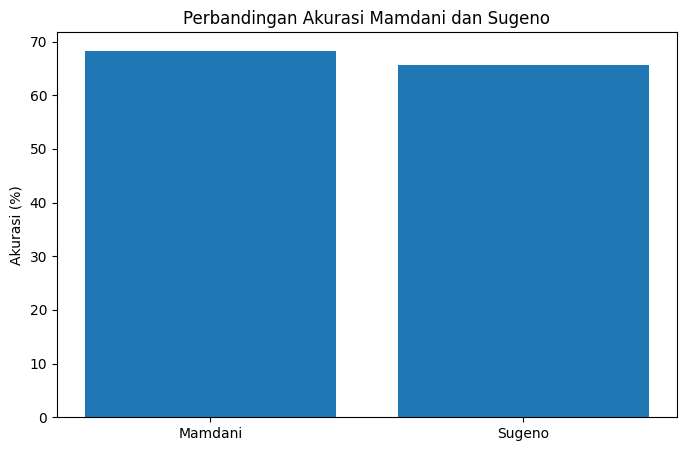


===== KESIMPULAN =====
Metode Mamdani lebih baik pada dataset ini.


In [17]:
metode = ["Mamdani", "Sugeno"]

akurasi = [
    accuracy_mamdani * 100,
    accuracy_sugeno * 100
]

plt.figure(figsize=(8,5))

plt.bar(
    metode,
    akurasi
)

plt.title(
    "Perbandingan Akurasi Mamdani dan Sugeno"
)

plt.ylabel("Akurasi (%)")

plt.show()

print("\n===== KESIMPULAN =====")

if accuracy_mamdani > accuracy_sugeno:

    print(
        "Metode Mamdani "
        "lebih baik pada dataset ini."
    )

elif accuracy_sugeno > accuracy_mamdani:

    print(
        "Metode Sugeno "
        "lebih baik pada dataset ini."
    )

else:

    print(
        "Kedua metode "
        "memiliki performa yang sama."
    )